In [ ]:
!pip install xgboost lightgbm keras-tuner seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.1 MB/s eta 0:00:00


In [ ]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

import joblib
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Load the dataset
dataset = pd.read_csv("/content/Concrete_Data_Yeh.csv")
dataset

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   flyash            1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarseaggregate   1030 non-null   float64
 6   fineaggregate     1030 non-null   float64
 7   age               1030 non-null   int64  
 8   csMPa             1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [ ]:
dataset.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [ ]:
# Checking for null values
dataset.isnull().sum()

,0
cement,0
slag,0
flyash,0
water,0
superplasticizer,0
coarseaggregate,0
fineaggregate,0
age,0
csMPa,0


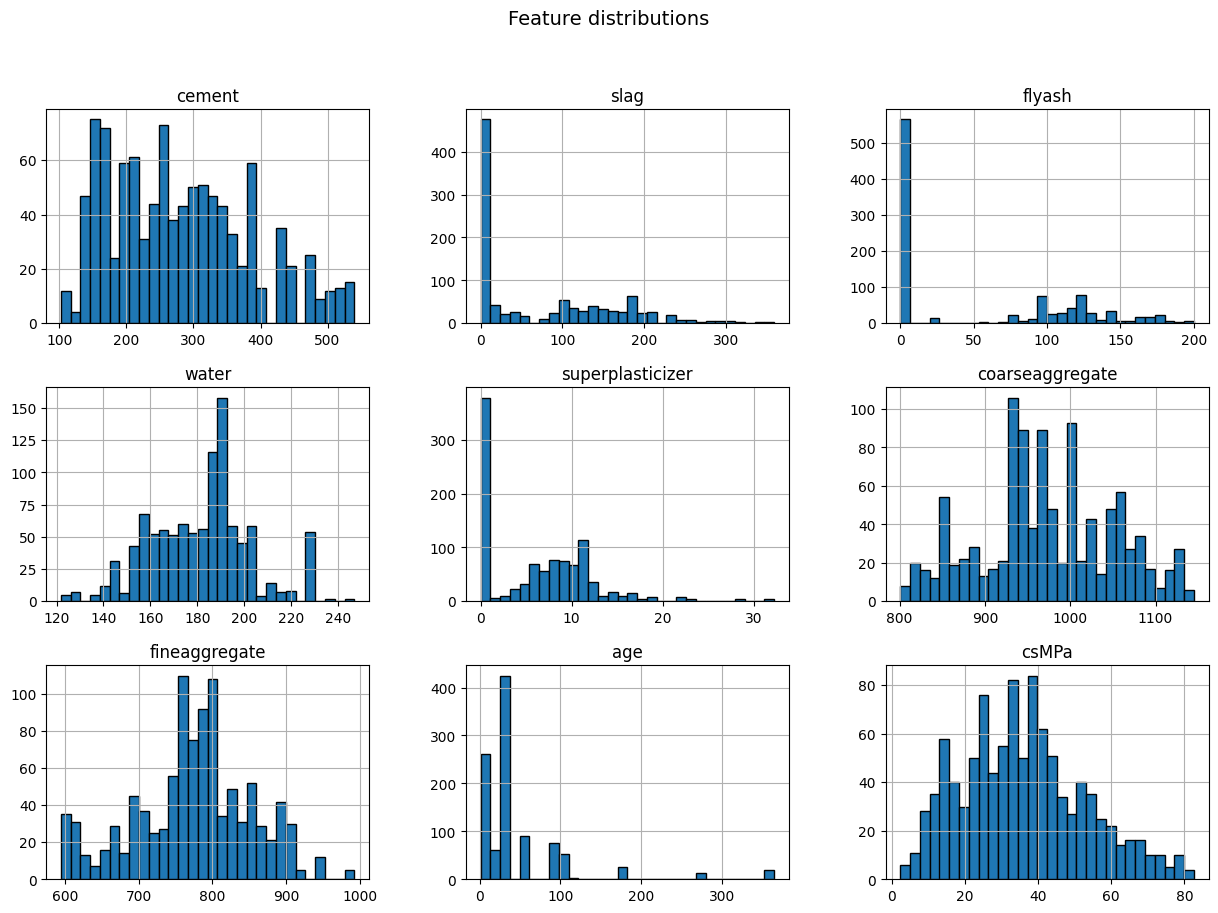

In [ ]:
# Histograms
dataset.hist(bins=30, figsize=(15,10), edgecolor='black')
plt.suptitle("Feature distributions", fontsize=14)
plt.show()

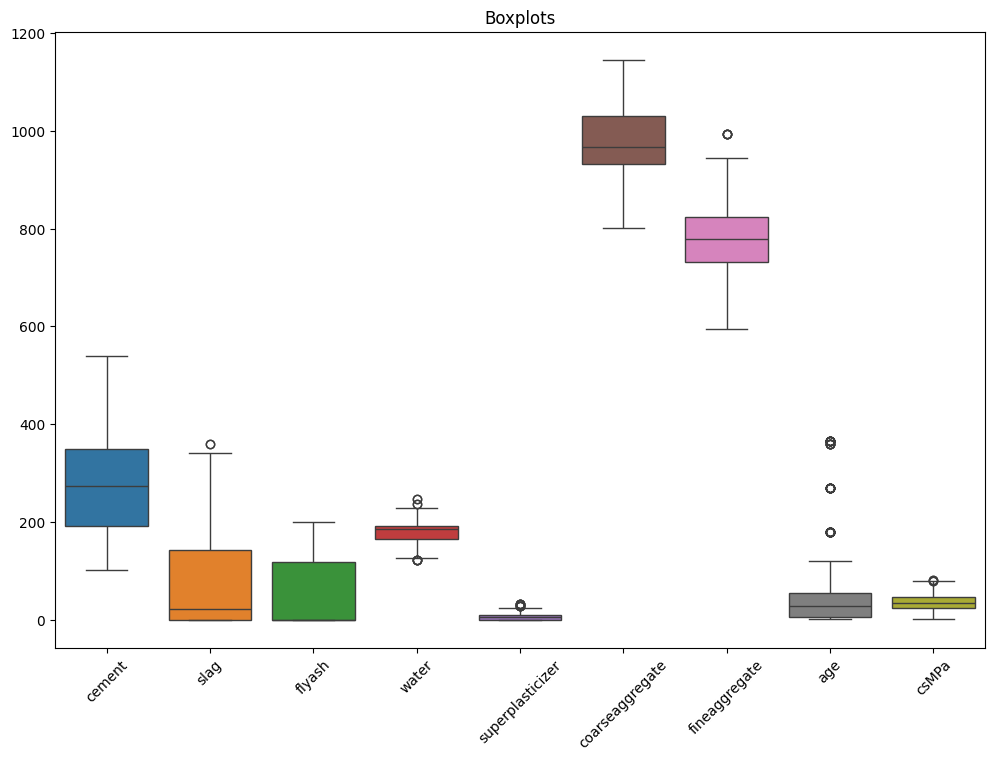

In [ ]:
# Boxplots
plt.figure(figsize=(12,8))
sns.boxplot(data=dataset)
plt.xticks(rotation=45)
plt.title("Boxplots")
plt.show()

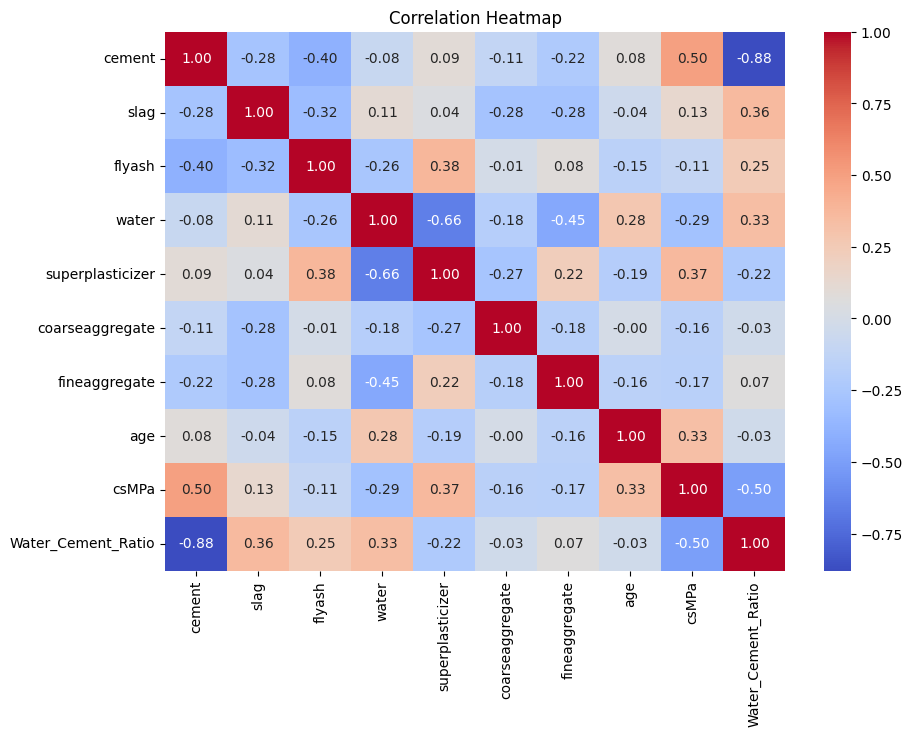

In [ ]:
# Correlation Matrix
plt.figure(figsize=(10,7))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

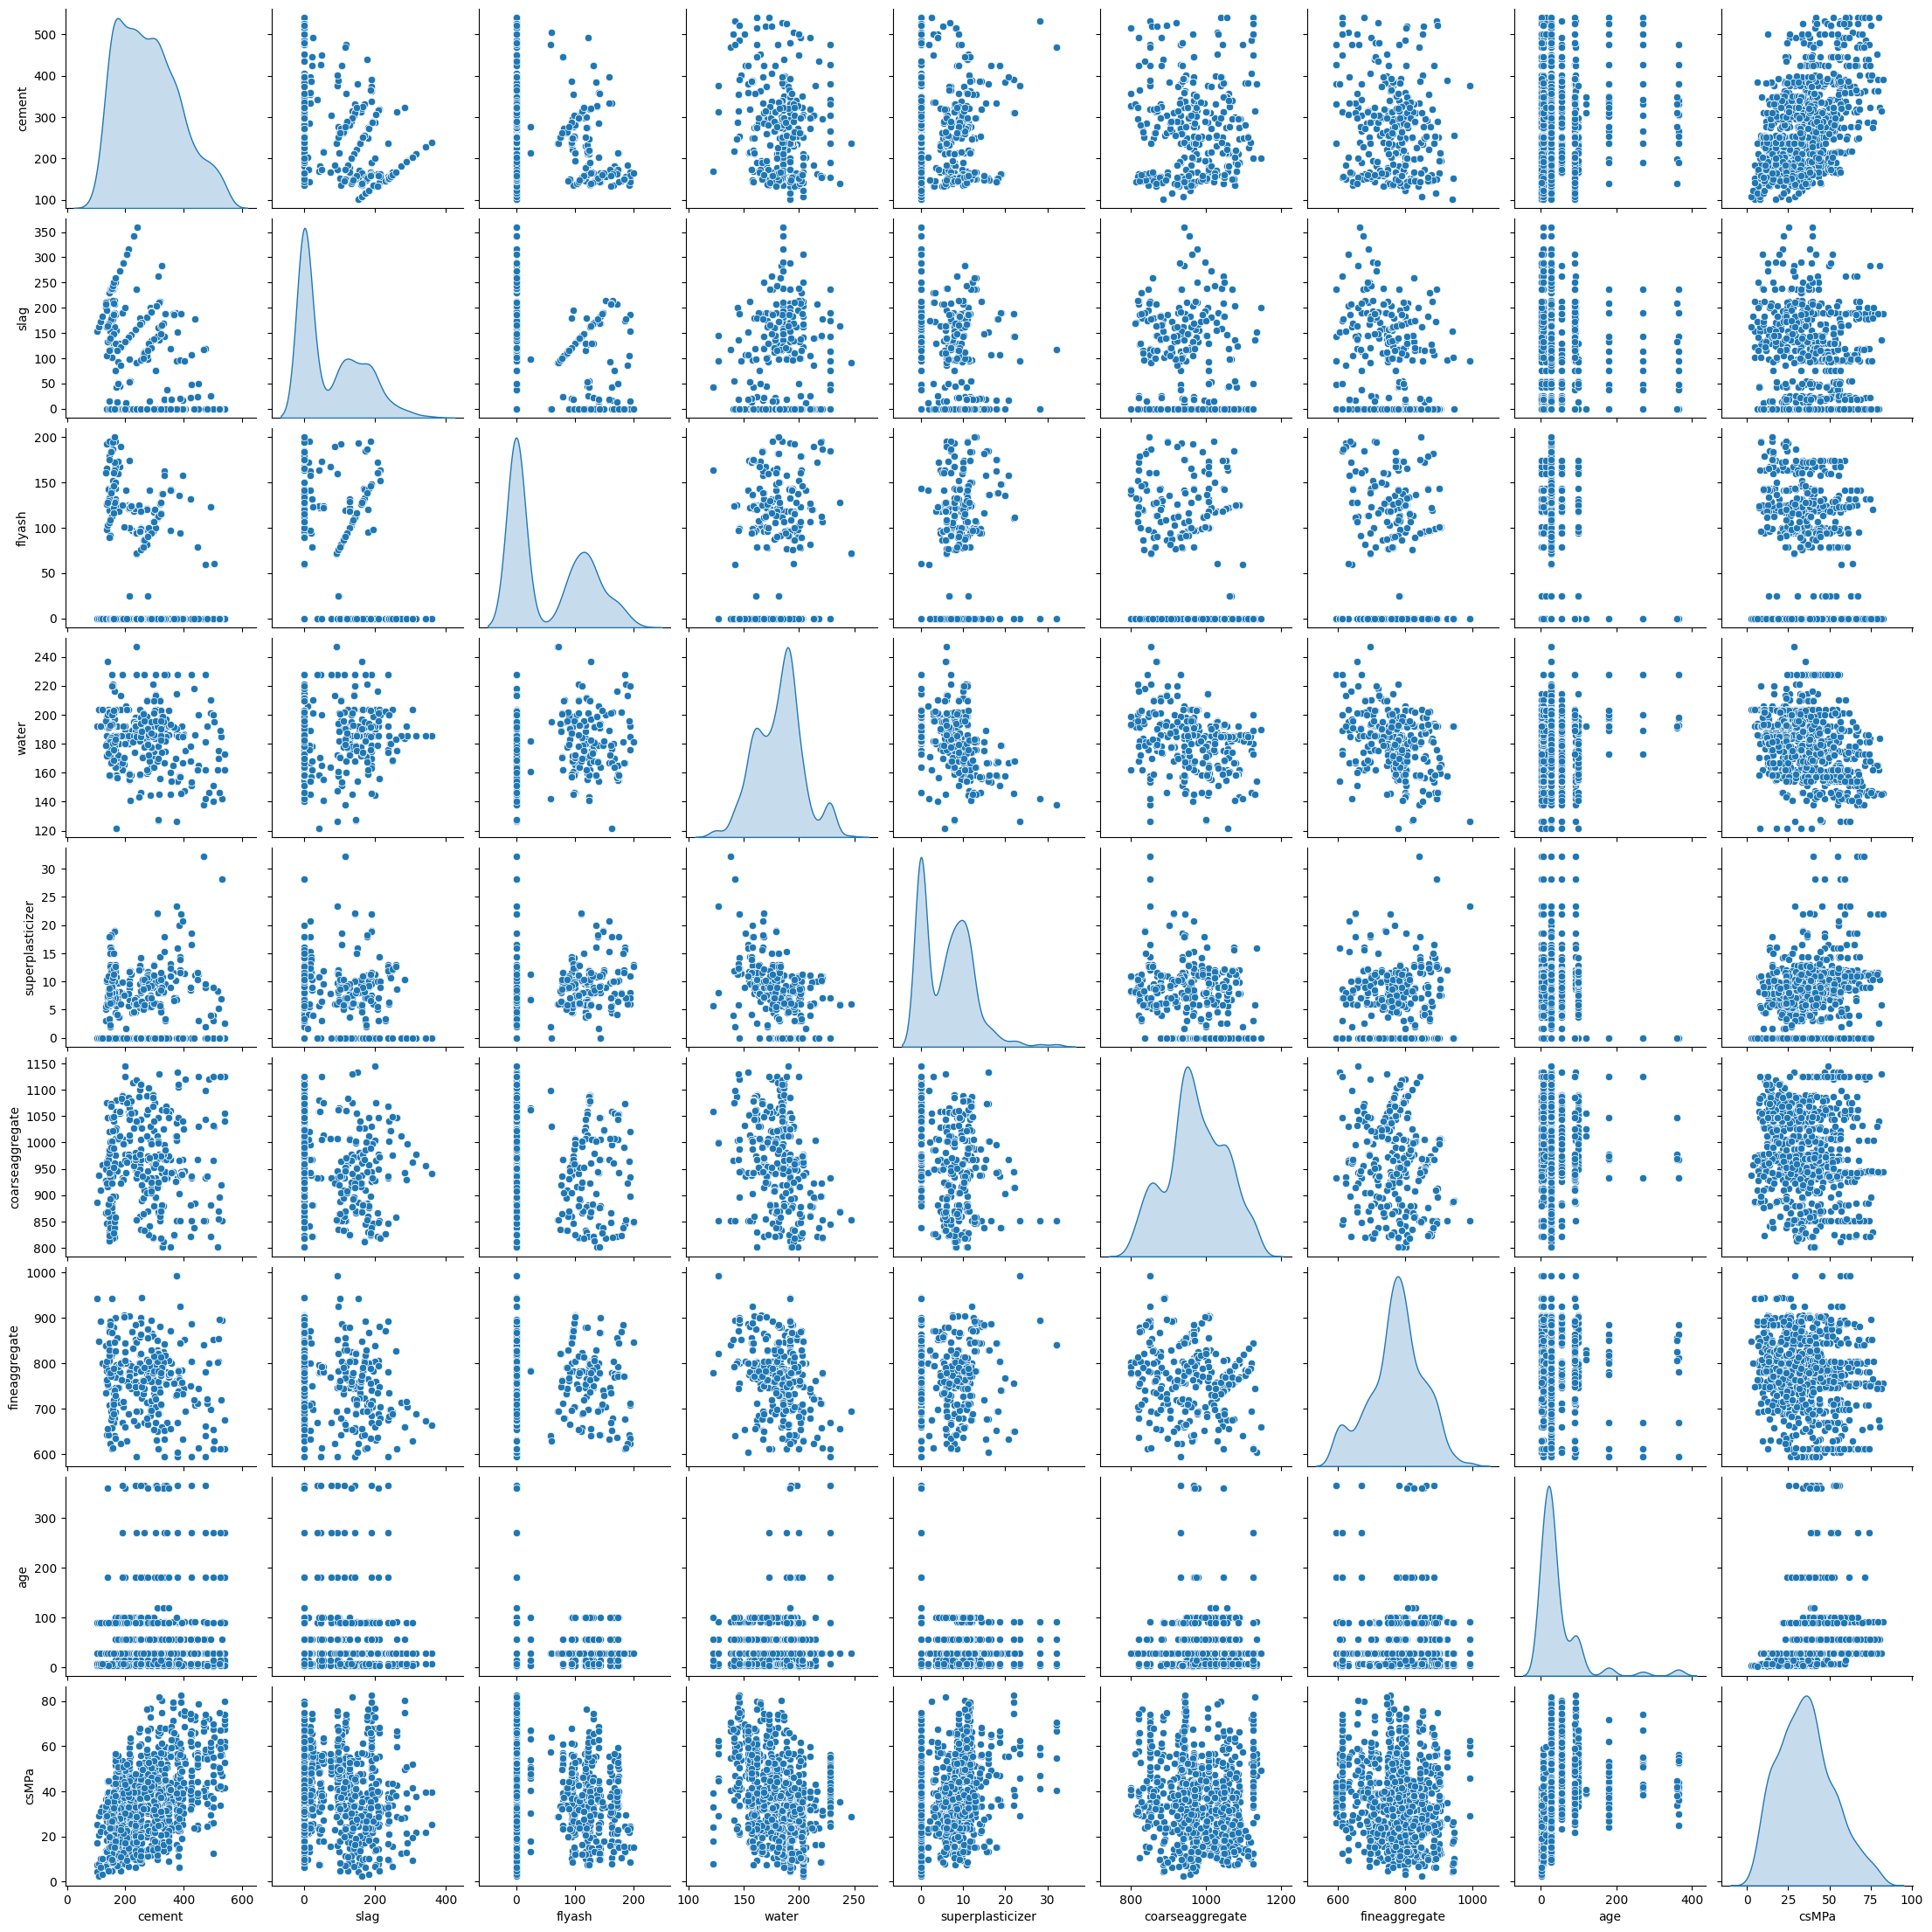

In [ ]:
# Pairplot
sns.pairplot(dataset, diag_kind="kde")
plt.show()

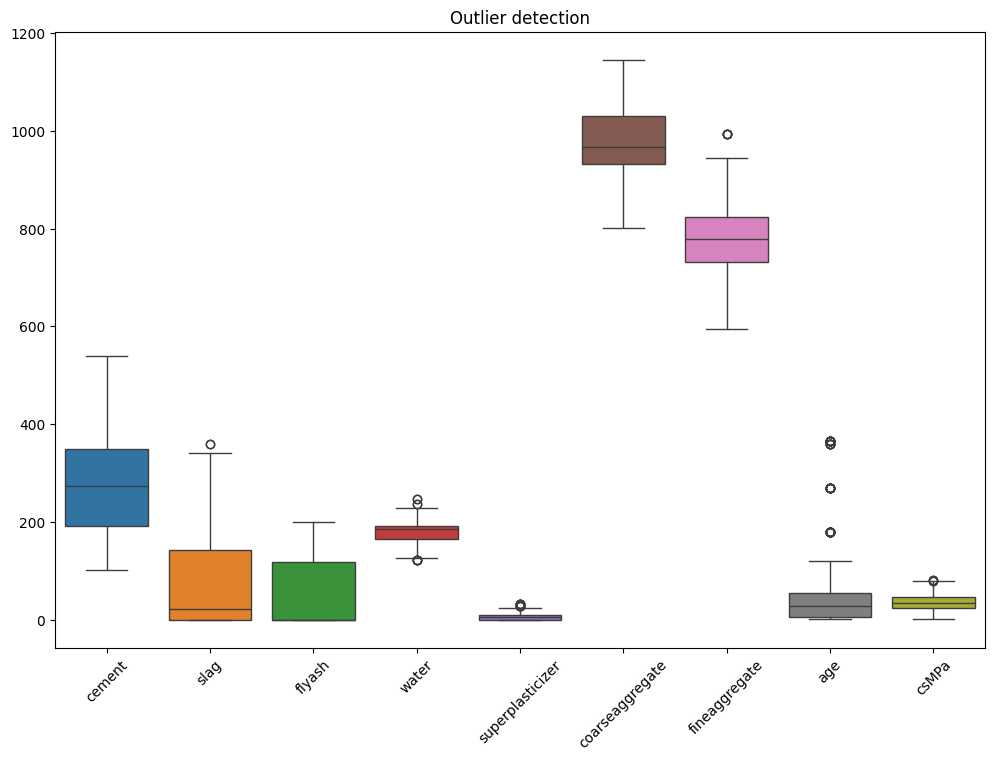

In [ ]:
# Plot boxplots for outlier detection
plt.figure(figsize=(12,8))
sns.boxplot(data=dataset)
plt.title("Outlier detection")
plt.xticks(rotation=45)
plt.show()

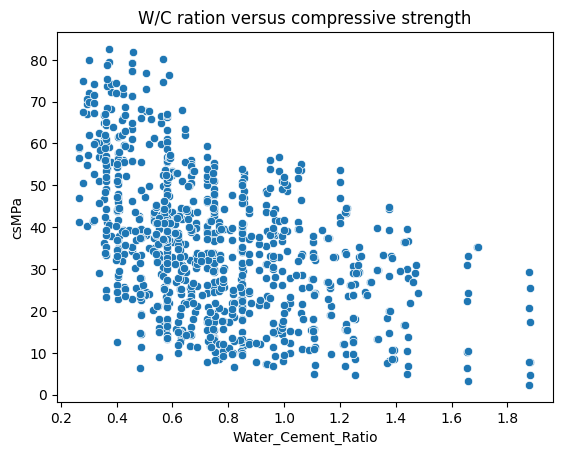

In [ ]:
# Feature Enginnering: Water per cement ratio
dataset["Water_Cement_Ratio"] = dataset["water"] / dataset["cement"]
sns.scatterplot(x=dataset["Water_Cement_Ratio"],
                y = dataset['csMPa'])
plt.title("W/C ration versus compressive strength")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Check the multicolinearity
X = dataset.drop('csMPa', axis=1)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
for i in range(len(X.columns))]
vif_data

,Feature,VIF
0,cement,46.690099
1,slag,3.686787
2,flyash,4.218240
3,water,140.906242
4,superplasticizer,5.473949
5,coarseaggregate,85.580168
6,fineaggregate,79.150969
7,age,1.705939
8,Water_Cement_Ratio,45.536429


In [ ]:
latex_table = vif_data.to_latex(
    index=False,
    float_format="%.4f",
    caption="Variance Inflation Factor (VIF) Analysis",
    label="tab:vif"
)

print(latex_table)

\begin{table}
\caption{Variance Inflation Factor (VIF) Analysis}
\label{tab:vif}
\begin{tabular}{lr}
\toprule
Feature & VIF \\
\midrule
cement & 46.6901 \\
slag & 3.6868 \\
flyash & 4.2182 \\
water & 140.9062 \\
superplasticizer & 5.4739 \\
coarseaggregate & 85.5802 \\
fineaggregate & 79.1510 \\
age & 1.7059 \\
Water_Cement_Ratio & 45.5364 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# Feature and target
y = dataset["csMPa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Evaluation Function
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return [name, rmse, mae, r2]

In [ ]:
results = []
best_models = {}

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

results.append(evaluate_model("Linear Regression", lr, X_test_scaled, y_test))
best_models["Linear Regression"] = lr

In [ ]:
# Ridge Regression (GridSearchCV)
ridge_params = {
    "alpha": np.logspace(-3, 2, 20)
}

ridge = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

ridge.fit(X_train_scaled, y_train)

results.append(
    evaluate_model("Ridge", ridge.best_estimator_, X_test_scaled, y_test)
)

best_models["Ridge"] = ridge.best_estimator_

print("Best Ridge:", ridge.best_params_)

Best Ridge: {'alpha': np.float64(2.636650898730358)}


In [ ]:
# Lasso Regression
lasso_params = {
    "alpha": np.logspace(-3, 1, 20)
}

lasso = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

lasso.fit(X_train_scaled, y_train)

results.append(
    evaluate_model("Lasso", lasso.best_estimator_, X_test_scaled, y_test)
)

best_models["Lasso"] = lasso.best_estimator_

print("Best Lasso:", lasso.best_params_)

Best Lasso: {'alpha': np.float64(0.001)}


In [ ]:
# Decision Tree (Heavy Tuning)
dt_params = {
    "max_depth": list(range(3, 30)),
    "min_samples_split": list(range(2, 20)),
    "min_samples_leaf": list(range(1, 10)),
    "criterion": ["squared_error", "friedman_mse"]
}

dt = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    n_iter=100,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

dt.fit(X_train, y_train)

results.append(
    evaluate_model("Decision Tree", dt.best_estimator_, X_test, y_test)
)

best_models["Decision Tree"] = dt.best_estimator_

print("Best Decision Tree:", dt.best_params_)

Best Decision Tree: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'squared_error'}


In [ ]:
# Random Forest (Heavy Tuning)
rf_params = {
    "n_estimators": [100,200,300,500,700,1000],
    "max_depth": [5,10,20,30,40,50,None],
    "min_samples_split": [2,5,10,15],
    "min_samples_leaf": [1,2,4,6],
    "max_features": ["sqrt","log2",None],
    "bootstrap": [True, False]
}

rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=120,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

results.append(
    evaluate_model("Random Forest", rf.best_estimator_, X_test, y_test)
)

best_models["Random Forest"] = rf.best_estimator_

print("Best RF:", rf.best_params_)

Best RF: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': False}


In [ ]:
# SVR (Heavy Tuning)
svr_params = {
    "C": [0.1,1,10,50,100,200],
    "gamma": ["scale","auto",0.01,0.001],
    "kernel": ["rbf","linear","poly"]
}

svr = GridSearchCV(
    SVR(),
    svr_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

svr.fit(X_train_scaled, y_train)

results.append(
    evaluate_model("SVR", svr.best_estimator_, X_test_scaled, y_test)
)

best_models["SVR"] = svr.best_estimator_

print("Best SVR:", svr.best_params_)

Best SVR: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}


In [ ]:
# Gradient Boosting (GBRT)
gbrt_params = {
    "n_estimators": [100,200,400,600],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "max_depth": [3,4,5,6,7],
    "min_samples_split": [2,5,10],
    "subsample": [0.6,0.8,1]
}

gbrt = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gbrt_params,
    n_iter=80,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

gbrt.fit(X_train, y_train)

results.append(
    evaluate_model("GBRT", gbrt.best_estimator_, X_test, y_test)
)

best_models["GBRT"] = gbrt.best_estimator_

print("Best GBRT:", gbrt.best_params_)

Best GBRT: {'subsample': 0.8, 'n_estimators': 600, 'min_samples_split': 10, 'max_depth': 4, 'learning_rate': 0.05}


In [ ]:
# XGBoost
xgb_params = {
    "n_estimators": [100,200,300,500],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "max_depth": [3,5,7,9],
    "subsample": [0.6,0.8,1],
    "colsample_bytree": [0.6,0.8,1],
    "gamma": [0,0.1,0.2]
}

xgb = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    n_iter=80,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)

results.append(
    evaluate_model("XGBoost", xgb.best_estimator_, X_test, y_test)
)

best_models["XGBoost"] = xgb.best_estimator_

print("Best XGB:", xgb.best_params_)

Best XGB: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [ ]:
# LightGBM
lgbm_params = {
    "n_estimators": [100,200,300,500],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "num_leaves": [20,30,40,50],
    "max_depth": [-1,5,10,20],
    "subsample": [0.6,0.8,1]
}

lgbm = RandomizedSearchCV(
    LGBMRegressor(random_state=42),
    lgbm_params,
    n_iter=80,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

lgbm.fit(X_train, y_train)

results.append(
    evaluate_model("LightGBM", lgbm.best_estimator_, X_test, y_test)
)

best_models["LightGBM"] = lgbm.best_estimator_

print("Best LGBM:", lgbm.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1219
[LightGBM] [Info] Number of data points in the train set: 824, number of used features: 9
[LightGBM] [Info] Start training from score 35.857864
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best LGBM: {'subsample': 0.8, 'num_leaves': 30, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.1}


In [ ]:
# ANN with Keras Tuner
def build_model(hp):

    model = keras.Sequential()

    model.add(layers.Dense(
        hp.Int("units1", 32, 256, step=32),
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ))

    for i in range(hp.Int("num_layers", 1, 4)):
        model.add(layers.Dense(
            hp.Int(f"units_{i}", 32, 256, step=32),
            activation="relu"
        ))

        model.add(layers.Dropout(
            hp.Float("dropout", 0.1, 0.5, step=0.1)
        ))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice("lr", [1e-2,1e-3,1e-4])
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    executions_per_trial=2,
    directory="ann_tuning",
    project_name="concrete"
)

tuner.search(
    X_train_scaled,
    y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=32
)

best_ann = tuner.get_best_models(1)[0]

best_ann.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

ann_pred = best_ann.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, ann_pred))
mae = mean_absolute_error(y_test, ann_pred)
r2 = r2_score(y_test, ann_pred)

results.append(["ANN", rmse, mae, r2])

best_models["ANN"] = best_ann

Trial 20 Complete [00h 00m 51s]
val_loss: 58.74301528930664

Best val_loss So Far: 27.142467498779297
Total elapsed time: 00h 16m 34s
Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 38.9719 - mae: 4.7215 - val_loss: 37.5776 - val_mae: 4.8132
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 34.8653 - mae: 4.5878 - val_loss: 39.6062 - val_mae: 4.9760
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 30.1533 - mae: 4.0766 - val_loss: 26.9171 - val_mae: 4.0000
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 20.1850 - mae: 3.4507 - val_loss: 26.5251 - val_mae: 3.8205
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 21.0258 - mae: 3.4454 - val_loss: 36.0916 - val_mae: 4.6351
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 31.7308 - mae: 4.2984 - val_loss: 37.6983 - val_mae: 4.7179
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28.6446 - mae: 3.9451 - val_loss: 46.6240 - val_mae: 5.0137
Epoch 8/150
21/21 ━━━━━━━━

In [ ]:
# Results Comparison
results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE", "R2"]
)

results_df = results_df.sort_values("RMSE")

results_df

,Model,RMSE,MAE,R2
6,GBRT,4.213607,2.807969,0.931098
8,LightGBM,4.434597,2.806461,0.923681
7,XGBoost,4.558025,3.240513,0.919373
4,Random Forest,5.344150,3.480535,0.889164
5,SVR,5.731817,4.041414,0.872500
9,ANN,5.775514,4.084065,0.870549
3,Decision Tree,6.028972,4.031869,0.858938
1,Ridge,9.727862,7.656912,0.632752
0,Linear Regression,9.729305,7.638487,0.632643
2,Lasso,9.729342,7.639484,0.632640


In [ ]:
latex_table = results_df.to_latex(
    index=False,
    float_format="%.4f",
    caption="Model Performance Comparison",
    label="tab:results"
)

print(latex_table)

\begin{table}
\caption{Model Performance Comparison}
\label{tab:results}
\begin{tabular}{lrrr}
\toprule
Model & RMSE & MAE & R2 \\
\midrule
GBRT & 4.2136 & 2.8080 & 0.9311 \\
LightGBM & 4.4346 & 2.8065 & 0.9237 \\
XGBoost & 4.5580 & 3.2405 & 0.9194 \\
Random Forest & 5.3442 & 3.4805 & 0.8892 \\
SVR & 5.7318 & 4.0414 & 0.8725 \\
ANN & 5.7755 & 4.0841 & 0.8705 \\
Decision Tree & 6.0290 & 4.0319 & 0.8589 \\
Ridge & 9.7279 & 7.6569 & 0.6328 \\
Linear Regression & 9.7293 & 7.6385 & 0.6326 \\
Lasso & 9.7293 & 7.6395 & 0.6326 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# Model compatibility check
model_capability = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "SVR",
        "GBRT",
        "XGBoost",
        "LightGBM",
        "ANN"
    ],

    "Nonlinear Learning": [
        "Low",
        "Low",
        "Low",
        "High",
        "High",
        "High",
        "Very High",
        "Very High",
        "Very High",
        "Very High"
    ],

    "Overfitting Control": [
        "High",
        "High",
        "High",
        "Low",
        "High",
        "Medium",
        "High",
        "Very High",
        "Very High",
        "Medium"
    ],

    "Speed": [
        "Very Fast",
        "Fast",
        "Fast",
        "Fast",
        "Medium",
        "Slow",
        "Medium",
        "Medium",
        "Fast",
        "Slow"
    ],

    "Interpretability": [
        "Very High",
        "High",
        "High",
        "Medium",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Very Low"
    ],

    "Robustness": [
        "Low",
        "Medium",
        "Medium",
        "Low",
        "High",
        "Medium",
        "High",
        "Very High",
        "Very High",
        "High"
    ],

    "Ensemble Role": [
        "Baseline",
        "Regularization",
        "Feature Selection",
        "Weak Learner",
        "Bagging",
        "Nonlinear Support",
        "Boosting",
        "Boosting",
        "Boosting",
        "Stacking"
    ]
})

model_capability

,Model,Nonlinear Learning,Overfitting Control,Speed,Interpretability,Robustness,Ensemble Role
0,Linear Regression,Low,High,Very Fast,Very High,Low,Baseline
1,Ridge,Low,High,Fast,High,Medium,Regularization
2,Lasso,Low,High,Fast,High,Medium,Feature Selection
3,Decision Tree,High,Low,Fast,Medium,Low,Weak Learner
4,Random Forest,High,High,Medium,Low,High,Bagging
5,SVR,High,Medium,Slow,Low,Medium,Nonlinear Support
6,GBRT,Very High,High,Medium,Low,High,Boosting
7,XGBoost,Very High,Very High,Medium,Low,Very High,Boosting
8,LightGBM,Very High,Very High,Fast,Low,Very High,Boosting
9,ANN,Very High,Medium,Slow,Very Low,High,Stacking


In [ ]:
capability_numeric = model_capability.copy()

capability_numeric = capability_numeric.replace({
    "Very Low": 1,
    "Low": 2,
    "Medium": 3,
    "High": 4,
    "Very High": 5,
    "Very Fast": 5,
    "Fast": 4,
    "Slow": 2,
    "Baseline": 1,
    "Regularization": 2,
    "Feature Selection": 2,
    "Weak Learner": 3,
    "Bagging": 4,
    "Nonlinear Support": 3,
    "Boosting": 5,
    "Stacking": 5
})

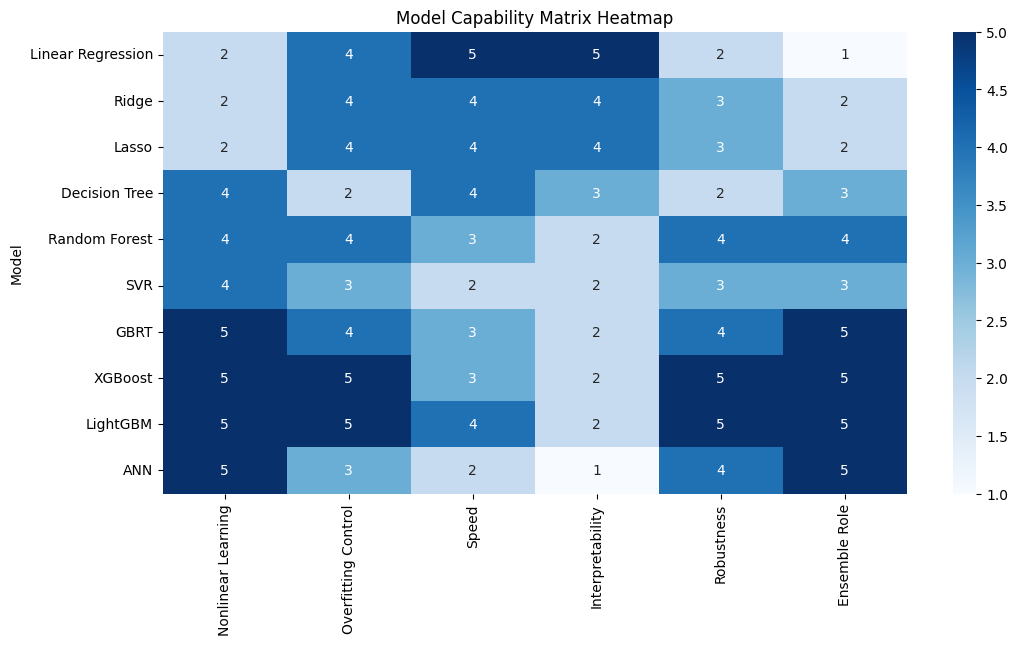

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    capability_numeric.set_index("Model"),
    annot=True,
    cmap="Blues"
)

plt.title("Model Capability Matrix Heatmap")
plt.show()

plt.savefig("model_capability_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
gbrt_best = best_models["GBRT"]
xgb_best  = best_models["XGBoost"]
lgb_best  = best_models["LightGBM"]

In [ ]:
gbrt_pred = gbrt_best.predict(X_test)
xgb_pred  = xgb_best.predict(X_test)
lgb_pred  = lgb_best.predict(X_test)

In [ ]:
# Train meta-learner only for weights
from sklearn.linear_model import LinearRegression
import numpy as np

# Create training stack
stack_X_train = np.column_stack([
    gbrt_best.predict(X_train),
    lgb_best.predict(X_train),
    xgb_best.predict(X_train)
])

# Train linear model to learn weights
meta_model = LinearRegression()
meta_model.fit(stack_X_train, y_train)

# Create test stack
stack_X_test = np.column_stack([
    gbrt_pred,
    lgb_pred,
    xgb_pred
])

# Final prediction
final_pred = meta_model.predict(stack_X_test)

In [ ]:
model_names = ["GBRT", "LightGBM", "XGBoost"]

for name, weight in zip(model_names, meta_model.coef_):
    print(f"{name}: {weight:.4f}")

print(f"Intercept: {meta_model.intercept_:.4f}")

GBRT: 0.4909
LightGBM: 0.7859
XGBoost: -0.2782
Intercept: 0.0502


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, final_pred))
mae = mean_absolute_error(y_test, final_pred)
r2 = r2_score(y_test, final_pred)

print("Final Hybrid Model")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

Final Hybrid Model
RMSE: 4.371425459426811
MAE: 2.7646031142861913
R2: 0.9258398367671093


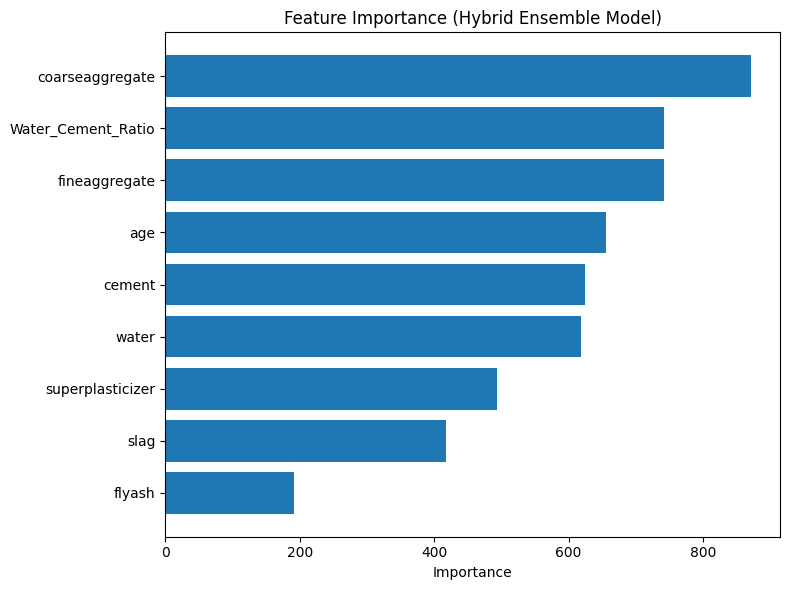

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract feature importance
fi_gbrt = best_models["GBRT"].feature_importances_
fi_xgb = best_models["XGBoost"].feature_importances_
fi_lgb = best_models["LightGBM"].feature_importances_

# Raw weights (from Ridge)
weights = np.array([0.4909, 0.7859, -0.2782])

# Fix weights
weights = np.maximum(weights, 0)
weights = weights / weights.sum()

# Weighted importance
ensemble_importance = (
    weights[0] * fi_gbrt +
    weights[1] * fi_lgb +
    weights[2] * fi_xgb
)

# SORTING
features = np.array(X_train.columns)

# Sort in descending order
indices = np.argsort(ensemble_importance)[::-1]

sorted_features = features[indices]
sorted_importance = ensemble_importance[indices]

# PLOT
plt.figure(figsize=(8, 6))

plt.barh(sorted_features, sorted_importance)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance (Hybrid Ensemble Model)")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

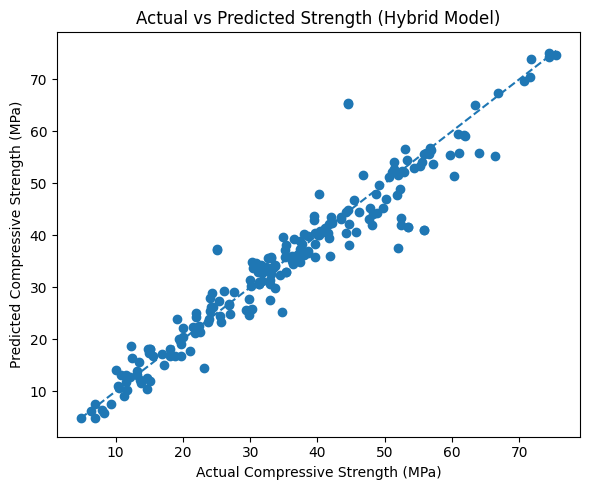

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, final_pred)
plt.xlabel("Actual Compressive Strength (MPa)")
plt.ylabel("Predicted Compressive Strength (MPa)")
plt.title("Actual vs Predicted Strength (Hybrid Model)")

# Perfect prediction line
min_val = min(y_test.min(), final_pred.min())
max_val = max(y_test.max(), final_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.tight_layout()
plt.savefig("actual_vs_pred.png", dpi=300)
plt.show()

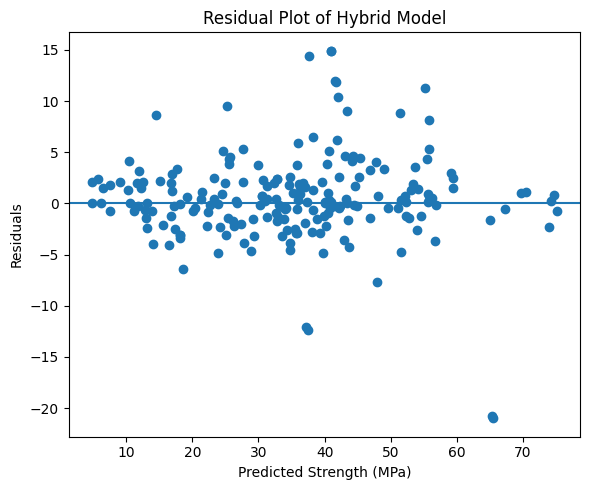

In [ ]:
residuals = y_test - final_pred

plt.figure(figsize=(6,5))
plt.scatter(final_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residuals")
plt.title("Residual Plot of Hybrid Model")

plt.tight_layout()
plt.savefig("residuals.png", dpi=300)
plt.show()

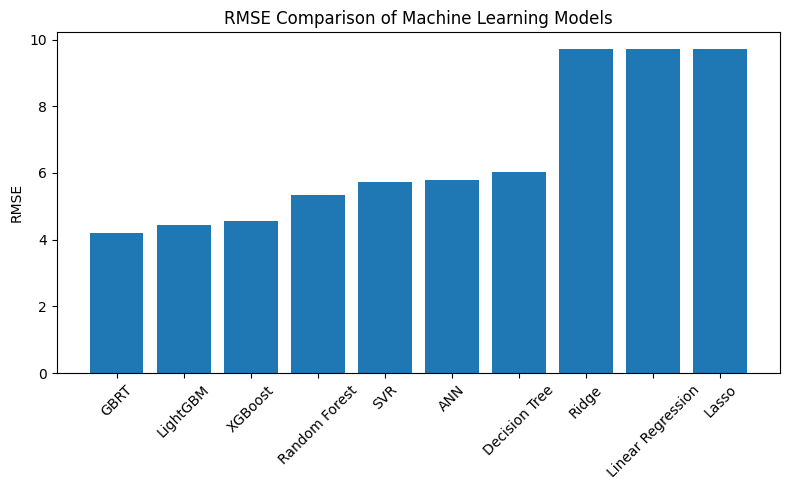

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Machine Learning Models")

plt.tight_layout()
plt.savefig("rmse_comparison.png", dpi=300)
plt.show()

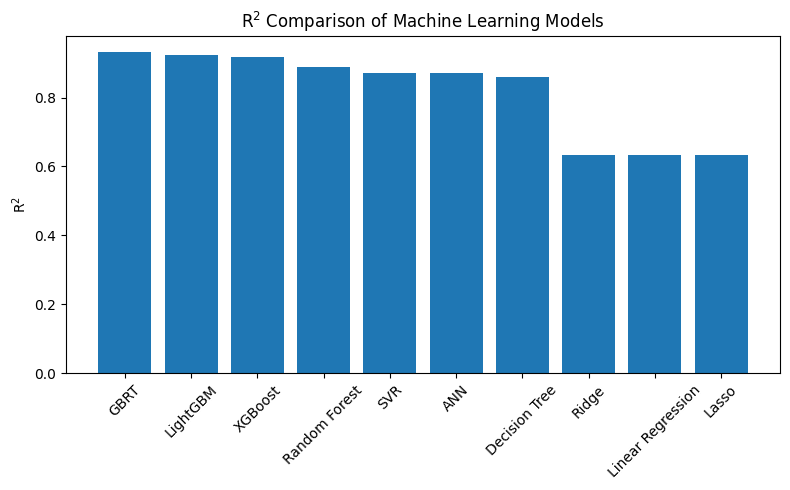

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45)
plt.ylabel("R$^2$")
plt.title("R$^2$ Comparison of Machine Learning Models")

plt.tight_layout()
plt.savefig("r2_comparison.png", dpi=300)
plt.show()

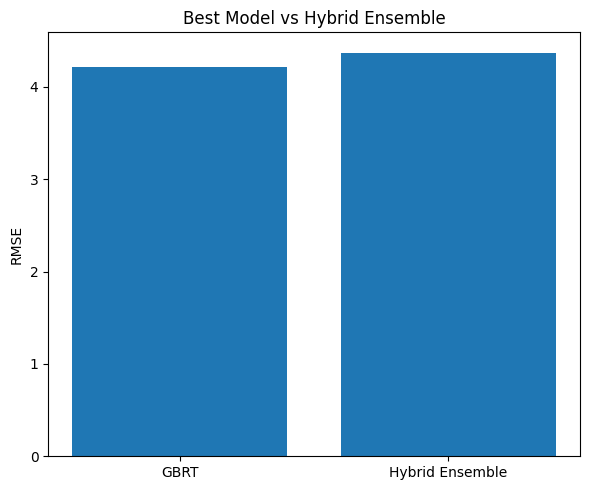

In [ ]:
models = ["GBRT", "Hybrid Ensemble"]
rmse_vals = [4.2136, 4.3714]

plt.figure(figsize=(6,5))
plt.bar(models, rmse_vals)
plt.ylabel("RMSE")
plt.title("Best Model vs Hybrid Ensemble")

plt.tight_layout()
plt.savefig("ensemble_vs_gbrt.png", dpi=300)
plt.show()

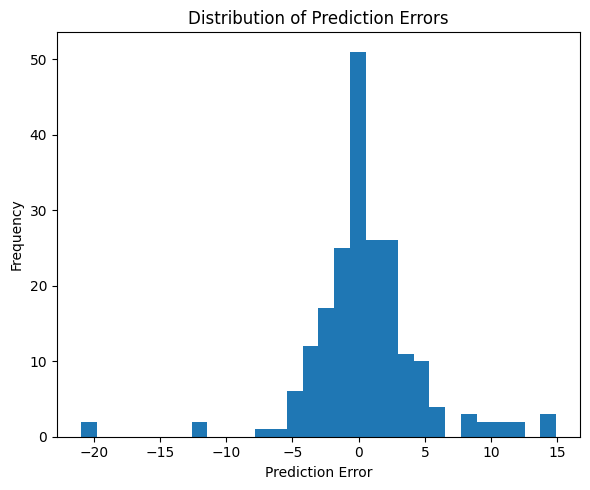

In [ ]:
errors = y_test - final_pred

plt.figure(figsize=(6,5))
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.savefig("error_distribution.png", dpi=300)
plt.show()